# Vertiefte EDA: Train1 vs. Train2 vs. Test
Analyse des Distribution Shifts zwischen den drei Datensätzen.

Schwerpunkte:
- Quantifizierung der Klassenimbalance
- Vergleich Bildgrößen und Bounding-Box-Statistiken
- Kameraverteilung und Domain-Unterschiede
- Visualisierung des Distribution Shifts

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")

data_dir   = "/datasets/multi-view-pig-posture-recognition/"
dir_train1 = os.path.join(data_dir, "train1_images")
dir_train2 = os.path.join(data_dir, "train2_images")
dir_test   = os.path.join(data_dir, "test_images")

train1_df = pd.read_csv(os.path.join(data_dir, "train1.csv"))
train2_df = pd.read_csv(os.path.join(data_dir, "train2.csv"))
test_df   = pd.read_csv(os.path.join(data_dir, "test.csv"))

CLASS_NAMES = {
    0: "Lateral_lying_left",
    1: "Lateral_lying_right",
    2: "Sitting",
    3: "Standing",
    4: "Sternal_lying"
}

def parse_bbox(x):
    if isinstance(x, str):
        try:
            return json.loads(x)
        except:
            return [float(i) for i in x.replace("[", "").replace("]", "").split(",")]
    return x

for df in [train1_df, train2_df, test_df]:
    df["bbox"] = df["bbox"].apply(parse_bbox)

print(f"Train1: {len(train1_df):>6} Samples")
print(f"Train2: {len(train2_df):>6} Samples")
print(f"Test:   {len(test_df):>6} Samples")

<jemalloc>: Unsupported system page size


Train1:  22934 Samples
Train2:  23450 Samples
Test:    11708 Samples


## 1. Grundlegende Datensatz-Statistiken im Vergleich

In [2]:
# Anzahl eindeutiger Bilder und Samples pro Datensatz
stats = pd.DataFrame({
    "Datensatz":         ["Train1", "Train2", "Test"],
    "Samples (Instanzen)": [len(train1_df), len(train2_df), len(test_df)],
    "Eindeutige Bilder": [
        train1_df["image_id"].nunique(),
        train2_df["image_id"].nunique(),
        test_df["image_id"].nunique()
    ],
    "Instanzen pro Bild (Ø)": [
        round(len(train1_df) / train1_df["image_id"].nunique(), 2),
        round(len(train2_df) / train2_df["image_id"].nunique(), 2),
        round(len(test_df)   / test_df["image_id"].nunique(), 2)
    ],
    "Bildbreite (häufigste)": [
        train1_df["width"].mode()[0],
        train2_df["width"].mode()[0],
        test_df["width"].mode()[0]
    ],
    "Bildhöhe (häufigste)": [
        train1_df["height"].mode()[0],
        train2_df["height"].mode()[0],
        test_df["height"].mode()[0]
    ],
})

print(stats.to_string(index=False))

Datensatz  Samples (Instanzen)  Eindeutige Bilder  Instanzen pro Bild (Ø)  Bildbreite (häufigste)  Bildhöhe (häufigste)
   Train1                22934               3090                    7.42                    1280                   720
   Train2                23450               3150                    7.44                    1280                   720
     Test                11708               1350                    8.67                    1280                   720


## 2. Klassenverteilung & Imbalance-Quantifizierung

In [3]:
# Absolute und relative Klassenverteilung für Train1 und Train2
t1_counts = train1_df["class_id"].value_counts().sort_index()
t2_counts = train2_df["class_id"].value_counts().sort_index()

imbalance_df = pd.DataFrame({
    "Klasse":      [f"{i}: {CLASS_NAMES[i]}" for i in range(5)],
    "Train1 Abs.": t1_counts.values,
    "Train1 %":    (t1_counts.values / len(train1_df) * 100).round(1),
    "Train2 Abs.": t2_counts.values,
    "Train2 %":    (t2_counts.values / len(train2_df) * 100).round(1),
})

# Imbalance-Ratio: häufigste Klasse / seltenste Klasse
ratio_t1 = t1_counts.max() / t1_counts.min()
ratio_t2 = t2_counts.max() / t2_counts.min()

print(imbalance_df.to_string(index=False))
print(f"\nImbalance-Ratio Train1: {ratio_t1:.1f}x  (Klasse {t1_counts.idxmax()} vs. Klasse {t1_counts.idxmin()})")
print(f"Imbalance-Ratio Train2: {ratio_t2:.1f}x  (Klasse {t2_counts.idxmax()} vs. Klasse {t2_counts.idxmin()})")
print(f"\n→ Macro F1 wird durch Klasse 2 (Sitting) besonders stark beeinflusst!")

                Klasse  Train1 Abs.  Train1 %  Train2 Abs.  Train2 %
 0: Lateral_lying_left         3053      13.3         3083      13.1
1: Lateral_lying_right         3376      14.7         3435      14.6
            2: Sitting          680       3.0          695       3.0
           3: Standing         9617      41.9         9928      42.3
      4: Sternal_lying         6208      27.1         6309      26.9

Imbalance-Ratio Train1: 14.1x  (Klasse 3 vs. Klasse 2)
Imbalance-Ratio Train2: 14.3x  (Klasse 3 vs. Klasse 2)

→ Macro F1 wird durch Klasse 2 (Sitting) besonders stark beeinflusst!


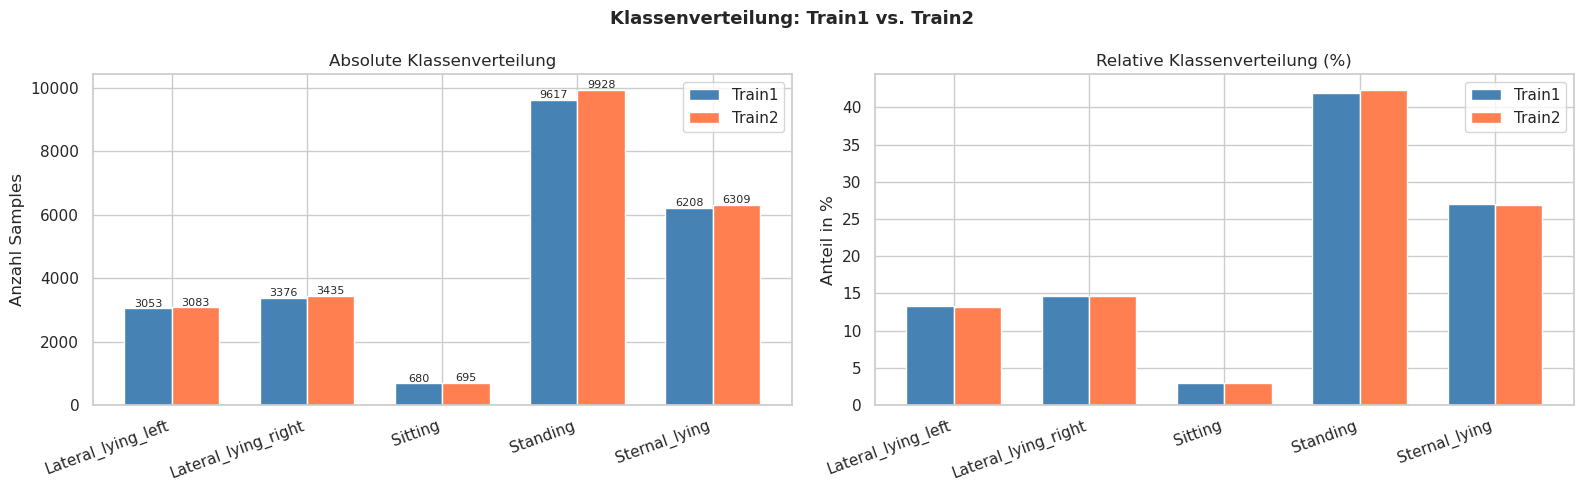

In [4]:
# Visualisierung: Klassenverteilung Train1 vs Train2 nebeneinander
x      = np.arange(5)
width  = 0.35
labels = [CLASS_NAMES[i] for i in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolut
axes[0].bar(x - width/2, t1_counts.values, width, label="Train1", color="steelblue")
axes[0].bar(x + width/2, t2_counts.values, width, label="Train2", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20, ha="right")
axes[0].set_title("Absolute Klassenverteilung")
axes[0].set_ylabel("Anzahl Samples")
axes[0].legend()
for i, (v1, v2) in enumerate(zip(t1_counts.values, t2_counts.values)):
    axes[0].text(i - width/2, v1 + 50, str(v1), ha="center", fontsize=8)
    axes[0].text(i + width/2, v2 + 50, str(v2), ha="center", fontsize=8)

# Relativ
t1_pct = t1_counts.values / len(train1_df) * 100
t2_pct = t2_counts.values / len(train2_df) * 100
axes[1].bar(x - width/2, t1_pct, width, label="Train1", color="steelblue")
axes[1].bar(x + width/2, t2_pct, width, label="Train2", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20, ha="right")
axes[1].set_title("Relative Klassenverteilung (%)")
axes[1].set_ylabel("Anteil in %")
axes[1].legend()

plt.suptitle("Klassenverteilung: Train1 vs. Train2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Kameraverteilung & Distribution Shift

In [5]:
# Kamera-ID aus image_id extrahieren
def extract_camera(image_id):
    parts = os.path.basename(str(image_id)).replace("-", "_").split("_")
    for part in parts:
        if part.lower().startswith("cam"):
            return part.lower()
    return "unknown"

def extract_pen(image_id):
    parts = os.path.basename(str(image_id)).replace("-", "_").split("_")
    for part in parts:
        if part.lower().startswith("pen"):
            return part.lower()
    return "unknown"

for df, name in [(train1_df, "Train1"), (train2_df, "Train2"), (test_df, "Test")]:
    df["camera"] = df["image_id"].apply(extract_camera)
    df["pen"]    = df["image_id"].apply(extract_pen)

# Übersicht
print("=== Kamera-Verteilung ===")
for name, df in [("Train1", train1_df), ("Train2", train2_df), ("Test", test_df)]:
    cam_counts = df["camera"].value_counts().sort_index()
    print(f"\n{name}:")
    for cam, cnt in cam_counts.items():
        print(f"  {cam}: {cnt} Samples ({cnt/len(df)*100:.1f}%)")

print("\n=== Pen-Verteilung ===")
for name, df in [("Train1", train1_df), ("Train2", train2_df), ("Test", test_df)]:
    pen_counts = df["pen"].value_counts().sort_index()
    print(f"\n{name}: {list(pen_counts.index)}")

=== Kamera-Verteilung ===

Train1:
  cam1: 13252 Samples (57.8%)
  cam2: 9682 Samples (42.2%)

Train2:
  cam1: 13452 Samples (57.4%)
  cam2: 9998 Samples (42.6%)

Test:
  cam1: 4264 Samples (36.4%)
  cam2: 7444 Samples (63.6%)

=== Pen-Verteilung ===

Train1: ['pen1', 'pen2']

Train2: ['pen1', 'pen2']

Test: ['pen1', 'pen2']


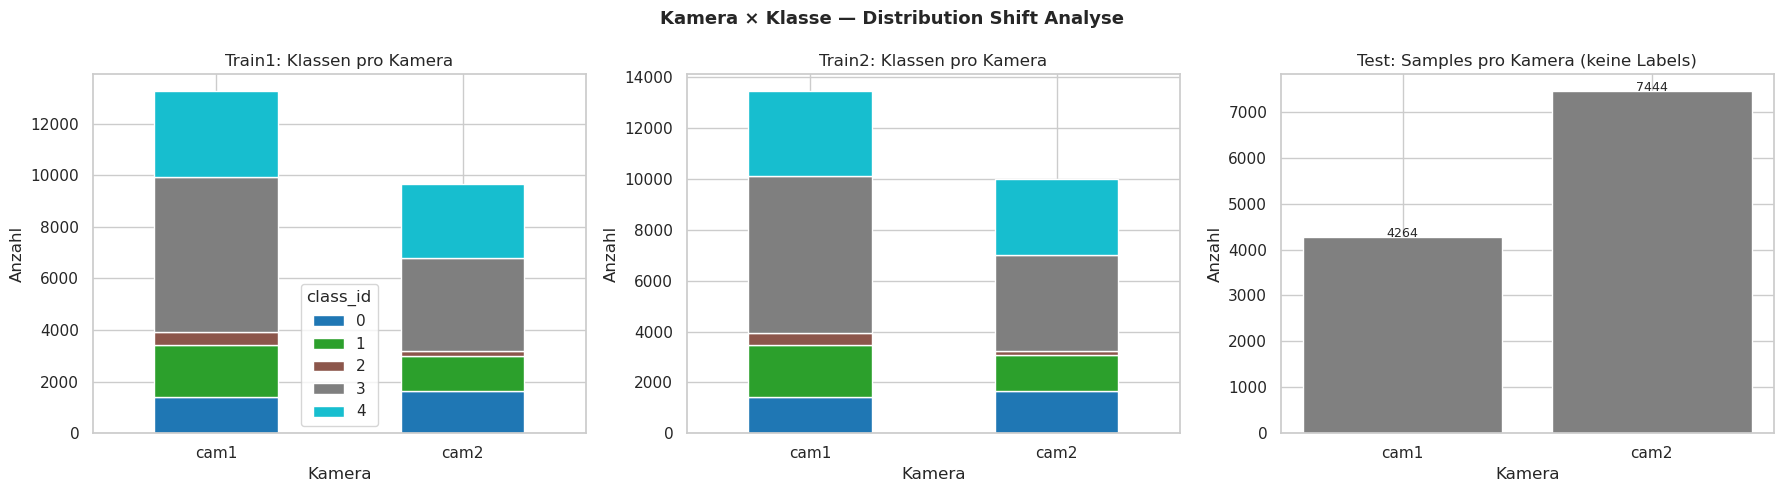


→ Wenn Train und Test unterschiedliche Kameras haben, liegt ein Distribution Shift vor!


In [6]:
# Klassenverteilung pro Kamera für alle drei Datensätze
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, [("Train1", train1_df), ("Train2", train2_df), ("Test", test_df)]):
    if "class_id" in df.columns:
        cam_class = df.groupby(["camera", "class_id"]).size().unstack(fill_value=0)
        cam_class.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", legend=(name == "Train1"))
        ax.set_title(f"{name}: Klassen pro Kamera")
        ax.set_xlabel("Kamera")
        ax.set_ylabel("Anzahl")
        ax.tick_params(axis="x", rotation=0)
    else:
        cam_counts = df["camera"].value_counts().sort_index()
        ax.bar(cam_counts.index, cam_counts.values, color="gray")
        ax.set_title(f"{name}: Samples pro Kamera (keine Labels)")
        ax.set_xlabel("Kamera")
        ax.set_ylabel("Anzahl")
        for cam, cnt in cam_counts.items():
            ax.text(cam, cnt + 20, str(cnt), ha="center", fontsize=9)

plt.suptitle("Kamera × Klasse — Distribution Shift Analyse", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n→ Wenn Train und Test unterschiedliche Kameras haben, liegt ein Distribution Shift vor!")

## 4. Bounding Box Vergleich: Train1 vs. Train2 vs. Test

In [7]:
# BBox-Statistiken berechnen
def bbox_stats(df, img_w, img_h):
    bboxes = pd.DataFrame(df["bbox"].tolist(), columns=["x", "y", "w", "h"])
    bboxes["aspect_ratio"] = bboxes["w"] / bboxes["h"]
    bboxes["area_norm"]    = (bboxes["w"] * bboxes["h"]) / (img_w * img_h)
    return bboxes

# Häufigste Auflösung als Normierungsbasis
bb1 = bbox_stats(train1_df, 1920, 1080)
bb2 = bbox_stats(train2_df, 1920, 1080)
bbt = bbox_stats(test_df,   1280,  720)

# Vergleichstabelle
bbox_compare = pd.DataFrame({
    "Datensatz":          ["Train1", "Train2", "Test"],
    "Breite Ø (px)":      [bb1["w"].mean().round(1), bb2["w"].mean().round(1), bbt["w"].mean().round(1)],
    "Höhe Ø (px)":        [bb1["h"].mean().round(1), bb2["h"].mean().round(1), bbt["h"].mean().round(1)],
    "Aspect Ratio Ø":     [bb1["aspect_ratio"].mean().round(3), bb2["aspect_ratio"].mean().round(3), bbt["aspect_ratio"].mean().round(3)],
    "Norm. Fläche Ø (%)":[round(bb1["area_norm"].mean()*100, 2), round(bb2["area_norm"].mean()*100, 2), round(bbt["area_norm"].mean()*100, 2)],
})
print(bbox_compare.to_string(index=False))

Datensatz  Breite Ø (px)  Höhe Ø (px)  Aspect Ratio Ø  Norm. Fläche Ø (%)
   Train1          298.2        294.7           1.173                4.55
   Train2          300.0        296.0           1.174                4.60
     Test          227.9        226.4           1.143                5.72


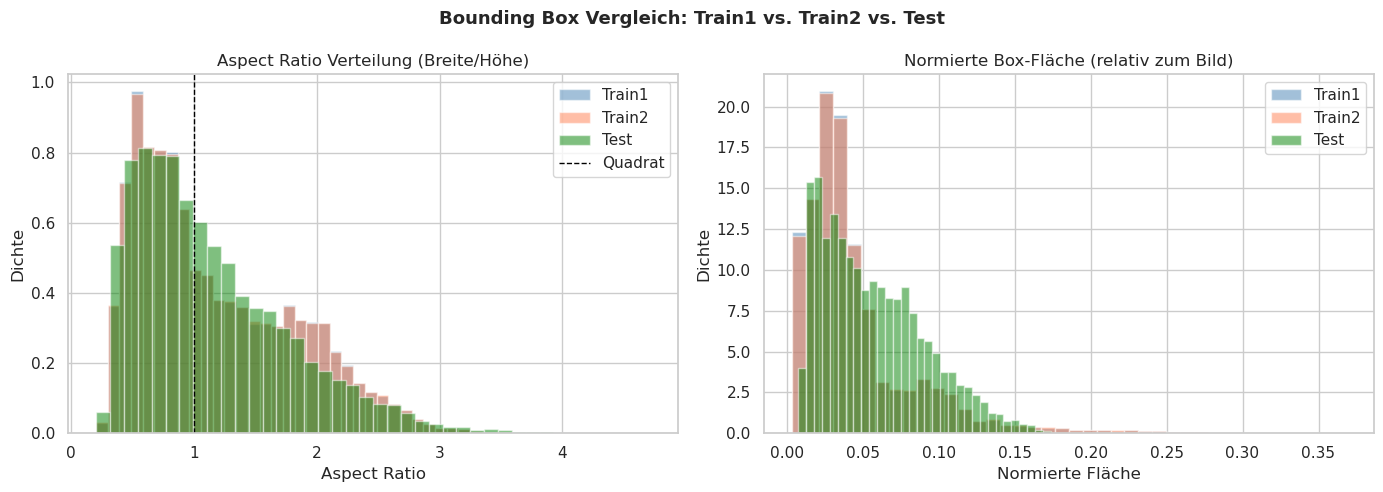

In [8]:
# Visualisierung: Aspect Ratio und normierte Fläche im Vergleich
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for data, label, color in [(bb1, "Train1", "steelblue"), (bb2, "Train2", "coral"), (bbt, "Test", "green")]:
    axes[0].hist(data["aspect_ratio"], bins=40, alpha=0.5, label=label, color=color, density=True)
    axes[1].hist(data["area_norm"],    bins=40, alpha=0.5, label=label, color=color, density=True)

axes[0].axvline(1, color="black", linestyle="--", linewidth=1, label="Quadrat")
axes[0].set_title("Aspect Ratio Verteilung (Breite/Höhe)")
axes[0].set_xlabel("Aspect Ratio")
axes[0].set_ylabel("Dichte")
axes[0].legend()

axes[1].set_title("Normierte Box-Fläche (relativ zum Bild)")
axes[1].set_xlabel("Normierte Fläche")
axes[1].set_ylabel("Dichte")
axes[1].legend()

plt.suptitle("Bounding Box Vergleich: Train1 vs. Train2 vs. Test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Klassenspezifische BBox-Analyse (Train2)

/tmp/ipykernel_624/3165683845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bb2, x="class_name", y="aspect_ratio", ax=axes[0], palette="tab10")
/tmp/ipykernel_624/3165683845.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bb2, x="class_name", y="area_norm", ax=axes[1], palette="tab10")


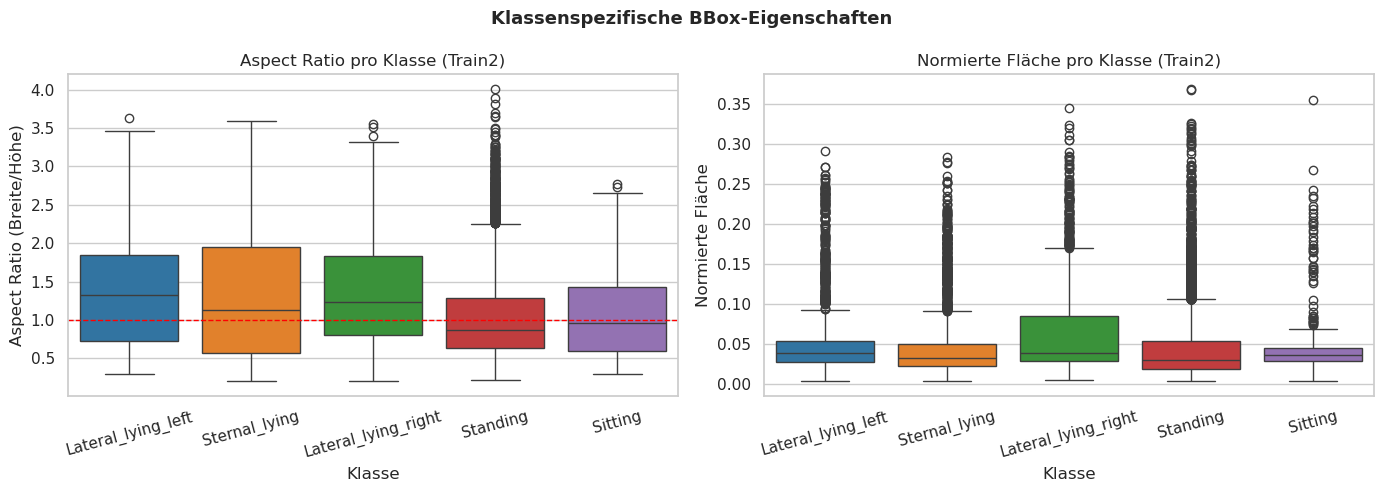

Mittlere Aspect Ratio pro Klasse:
class_name
Lateral_lying_left     1.337
Lateral_lying_right    1.342
Sitting                1.069
Standing               1.018
Sternal_lying          1.260


In [9]:
# Aspect Ratio pro Klasse — macht Sinn, da Haltungen unterschiedliche Formen haben
bb2["class_id"] = train2_df["class_id"].values
bb2["class_name"] = bb2["class_id"].map(CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=bb2, x="class_name", y="aspect_ratio", ax=axes[0], palette="tab10")
axes[0].set_title("Aspect Ratio pro Klasse (Train2)")
axes[0].set_xlabel("Klasse")
axes[0].set_ylabel("Aspect Ratio (Breite/Höhe)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].axhline(1, color="red", linestyle="--", linewidth=1)

sns.boxplot(data=bb2, x="class_name", y="area_norm", ax=axes[1], palette="tab10")
axes[1].set_title("Normierte Fläche pro Klasse (Train2)")
axes[1].set_xlabel("Klasse")
axes[1].set_ylabel("Normierte Fläche")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Klassenspezifische BBox-Eigenschaften", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Mittlere Aspect Ratio pro Klasse:")
print(bb2.groupby("class_name")["aspect_ratio"].mean().round(3).to_string())

## 6. Zusammenfassung der EDA-Erkenntnisse

In [10]:
print("="*60)
print("ZUSAMMENFASSUNG DER EDA-ERKENNTNISSE")
print("="*60)

print(f"""
1. DATENSATZGRÖSSE
   - Train1: {len(train1_df)} Samples | Train2: {len(train2_df)} Samples | Test: {len(test_df)} Samples
   - Train2 ist der größere und wichtigere Datensatz

2. KLASSENIMBALANCE (kritisch für Macro F1!)
   - Train2 Imbalance-Ratio: {ratio_t2:.1f}x  (Klasse 3 vs. Klasse 2)
   - Klasse 2 (Sitting) ist stark unterrepräsentiert
   - → WeightedRandomSampler und class-weighted Loss sind notwendig

3. DISTRIBUTION SHIFT
    - Alle Datensätze nutzen hauptsächlich 1280×720px Bilder
    - Train und Test haben dieselben Kameras (cam1, cam2)
    - Der Shift liegt im Kamera-Verhältnis: Train 58% cam1 / Test 36% cam1
    - Test hat mehr cam2-Daten → Modell muss auf cam2-Perspektive generalisieren

4. BOUNDING BOXES
   - Schweine sind oft quer im Bild (Aspect Ratio > 1)
   - Sternal_lying und Lateral_lying haben höheren Aspect Ratio
   - Siting hat kompaktere Boxen (Aspect Ratio ≈ 1)
   - → Bbox-Crop sinnvoll, ggf. mit kleinem Padding für Kontext
""")

ZUSAMMENFASSUNG DER EDA-ERKENNTNISSE

1. DATENSATZGRÖSSE
   - Train1: 22934 Samples | Train2: 23450 Samples | Test: 11708 Samples
   - Train2 ist der größere und wichtigere Datensatz

2. KLASSENIMBALANCE (kritisch für Macro F1!)
   - Train2 Imbalance-Ratio: 14.3x  (Klasse 3 vs. Klasse 2)
   - Klasse 2 (Sitting) ist stark unterrepräsentiert
   - → WeightedRandomSampler und class-weighted Loss sind notwendig

3. DISTRIBUTION SHIFT
    - Alle Datensätze nutzen hauptsächlich 1280×720px Bilder
    - Train und Test haben dieselben Kameras (cam1, cam2)
    - Der Shift liegt im Kamera-Verhältnis: Train 58% cam1 / Test 36% cam1
    - Test hat mehr cam2-Daten → Modell muss auf cam2-Perspektive generalisieren

4. BOUNDING BOXES
   - Schweine sind oft quer im Bild (Aspect Ratio > 1)
   - Sternal_lying und Lateral_lying haben höheren Aspect Ratio
   - Siting hat kompaktere Boxen (Aspect Ratio ≈ 1)
   - → Bbox-Crop sinnvoll, ggf. mit kleinem Padding für Kontext

